# Regime Detection - Trending vs Mean-Reverting vs Choppy

**Purpose:** Classify each day and each intraday window into a market regime.  
**Why it matters:** Market making only works in mean-reverting / choppy regimes.  
In trending regimes, the MM loses money on every fill because price keeps moving away.

## The Core Problem
On May 15, most symbols lost money despite shallow queues and reasonable vol.  
The likely cause: **trending price action** — price moved directionally and our  
symmetric quotes kept getting hit on the wrong side.

## Regimes We're Detecting
1. **Mean-reverting (GOOD for MM)** - price oscillates around a level, fills on both sides
2. **Choppy/ranging (GOOD for MM)** - low vol, tight range, fills accumulate slowly
3. **Trending (BAD for MM)** - price moves directionally, inventory builds on wrong side
4. **Volatile/jumpy (NEUTRAL-BAD)** - large random moves, high adverse selection risk

## Methods We'll Use
1. **Hurst Exponent** - H < 0.5 = mean-reverting, H > 0.5 = trending, H = 0.5 = random walk
2. **Autocorrelation of returns** - negative autocorr = mean-reverting, positive = trending
3. **Variance Ratio Test** - VR < 1 = mean-reverting, VR > 1 = trending
4. **Price range / vol ratio** - (high-low) / realized_vol as trending strength indicator
5. **Rolling regime classification** - label each 15-min window as T/MR/C

## Available Data
```
close, open, high, low      - OHLC per 1s bar
price_mom_10s/30s/60s       - price momentum at multiple windows
realized_vol_10s/30s/60s    - realized vol
volume_delta                - buy - sell volume
spread_zscore               - spread vs recent history
```

---

## 0. Imports & Config

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gcsfs
from matplotlib.patches import Patch
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

GCP_PROJECT  = 'hedge-fund-494103'
GCS_BUCKET   = 'hedge-fund-494103-marketdata'
GCS_PREFIX   = 'processed/features'
FINDINGS_DIR = '../findings'

SYMBOLS = [
    'CHOLAFIN26MAYFUT',
    'ADANIPORTS26MAYFUT',
    'DRREDDY26MAYFUT',
    'ADANIENT26MAYFUT',
    'HAVELLS26MAYFUT',
    'JSWSTEEL26MAYFUT',
    'RELIANCE26MAYFUT',
]

DATES = ['2026-05-13', '2026-05-14', '2026-05-15']

# Regime labels
TRENDING      = 'TRENDING'
MEAN_REVERTING = 'MEAN_REVERTING'
CHOPPY        = 'CHOPPY'
VOLATILE      = 'VOLATILE'

REGIME_COLORS = {
    TRENDING:       '#ff4444',
    MEAN_REVERTING: '#00ff88',
    CHOPPY:         '#00d4ff',
    VOLATILE:       '#ffd700',
}

os.makedirs(FINDINGS_DIR, exist_ok=True)
print('Config loaded.')

c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Config loaded.


c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


## 1. Load Data

In [2]:
fs = gcsfs.GCSFileSystem(project=GCP_PROJECT)

def load_symbol(symbol: str, dates: list) -> pd.DataFrame:
    frames = []
    for date in dates:
        path = f"{GCS_BUCKET}/{GCS_PREFIX}/{symbol}/{date}.parquet"
        if not fs.exists(path):
            print(f'  [MISS] {symbol} / {date}')
            continue
        df = pd.read_parquet(f"gs://{path}")
        df['date'] = date
        frames.append(df)
        print(f'  [OK]   {symbol} / {date} — {len(df):,} bars')
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True).sort_values('ts_sec').reset_index(drop=True)
    out['ist_tod_sec'] = (out['ts_sec'] + 19800) % 86400
    out['ist_hhmm']    = out['ist_tod_sec'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    # Market hours filter
    out = out[(out['ist_hhmm'] >= '09:15') & (out['ist_hhmm'] <= '15:30')]
    out = out.reset_index(drop=True)
    return out


symbol_data = {}
for sym in SYMBOLS:
    print(f'Loading {sym}...')
    df = load_symbol(sym, DATES)
    if not df.empty:
        symbol_data[sym] = df

print(f'\nLoaded {len(symbol_data)}/{len(SYMBOLS)} symbols')

Loading CHOLAFIN26MAYFUT...
  [OK]   CHOLAFIN26MAYFUT / 2026-05-13 — 18,244 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-14 — 17,959 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-15 — 19,156 bars
Loading ADANIPORTS26MAYFUT...
  [OK]   ADANIPORTS26MAYFUT / 2026-05-13 — 19,859 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-14 — 19,188 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-15 — 19,876 bars
Loading DRREDDY26MAYFUT...
  [OK]   DRREDDY26MAYFUT / 2026-05-13 — 20,205 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-14 — 11,551 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-15 — 11,579 bars
Loading ADANIENT26MAYFUT...
  [OK]   ADANIENT26MAYFUT / 2026-05-13 — 17,422 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-14 — 20,602 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-15 — 20,682 bars
Loading HAVELLS26MAYFUT...
  [OK]   HAVELLS26MAYFUT / 2026-05-13 — 18,068 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-14 — 17,384 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-15 — 18,390 bars
Loading JSWSTEEL26MAYFUT...
  [OK]   JSWSTEEL26MAYFUT / 2026-05-1

## 2. Return Autocorrelation

Simplest regime test: autocorrelation of 1-second returns.
- **Negative autocorr** → price reverts → mean-reverting → GOOD for MM
- **Positive autocorr** → price follows through → trending → BAD for MM
- **Near zero** → random walk → neutral

We test at multiple lags (1s, 5s, 10s, 30s) to understand at which timescale the signal operates.

In [3]:
def return_autocorr(df: pd.DataFrame, lags: list = [1, 5, 10, 30, 60]) -> dict:
    df2  = df.sort_values('ts_sec').copy()
    rets = df2['close'].pct_change().dropna()
    rets = rets[rets.abs() < rets.abs().quantile(0.99)]  # remove outliers

    result = {}
    for lag in lags:
        if lag >= len(rets):
            continue
        corr = float(rets.autocorr(lag=lag))
        result[f'acf_lag{lag}'] = round(corr, 4)

    # Overall character based on lag-1 autocorr
    lag1 = result.get('acf_lag1', 0)
    if lag1 < -0.05:
        result['character'] = MEAN_REVERTING
    elif lag1 > 0.05:
        result['character'] = TRENDING
    else:
        result['character'] = CHOPPY

    return result


autocorr_results = {}
print(f"{'Symbol':30s} {'ACF-1':>8} {'ACF-5':>8} {'ACF-10':>8} {'ACF-30':>8} {'ACF-60':>8} {'Character':>15}")
print('-' * 92)

for sym, df in symbol_data.items():
    res = return_autocorr(df)
    autocorr_results[sym] = res
    char = res['character']
    print(f"{sym:30s} "
          f"{res.get('acf_lag1', 0):>8.4f} "
          f"{res.get('acf_lag5', 0):>8.4f} "
          f"{res.get('acf_lag10', 0):>8.4f} "
          f"{res.get('acf_lag30', 0):>8.4f} "
          f"{res.get('acf_lag60', 0):>8.4f} "
          f"{char:>15}")

print()
print('Negative = mean-reverting (GOOD for MM) | Positive = trending (BAD for MM)')

Symbol                            ACF-1    ACF-5   ACF-10   ACF-30   ACF-60       Character
--------------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                -0.0157  -0.0085  -0.0023   0.0012  -0.0025          CHOPPY
ADANIPORTS26MAYFUT              -0.0648  -0.0090   0.0022   0.0102   0.0038  MEAN_REVERTING
DRREDDY26MAYFUT                 -0.1169   0.0151  -0.0053   0.0031  -0.0122  MEAN_REVERTING
ADANIENT26MAYFUT                -0.1241  -0.0081  -0.0108  -0.0065  -0.0042  MEAN_REVERTING
HAVELLS26MAYFUT                 -0.0217   0.0036   0.0017  -0.0021   0.0003          CHOPPY
JSWSTEEL26MAYFUT                -0.0968  -0.0029  -0.0088   0.0009   0.0065  MEAN_REVERTING
RELIANCE26MAYFUT                -0.1392  -0.0109  -0.0010  -0.0017   0.0059  MEAN_REVERTING

Negative = mean-reverting (GOOD for MM) | Positive = trending (BAD for MM)


## 3. Autocorrelation by Day

Was May 15 more trending than May 13/14? This directly explains the bad backtest.

In [4]:
daily_autocorr = {}

print('Return autocorrelation (lag=1) by day:')
print(f"{'Symbol':30s} {'May-13':>10} {'May-14':>10} {'May-15':>10} {'Trend on 15?':>14}")
print('-' * 78)

for sym, df in symbol_data.items():
    day_acf = {}
    for date in DATES:
        day_df = df[df['date'] == date].sort_values('ts_sec')
        if len(day_df) < 100:
            day_acf[date] = np.nan
            continue
        rets = day_df['close'].pct_change().dropna()
        day_acf[date] = round(float(rets.autocorr(lag=1)), 4)

    daily_autocorr[sym] = day_acf

    a13 = day_acf.get('2026-05-13', np.nan)
    a14 = day_acf.get('2026-05-14', np.nan)
    a15 = day_acf.get('2026-05-15', np.nan)

    # Was May 15 more trending (higher/less negative autocorr)?
    trend15 = 'MORE TREND' if (not np.isnan(a15) and not np.isnan(a13) and a15 > a13 + 0.02) else 'similar'

    print(f"{sym:30s} {str(a13):>10} {str(a14):>10} {str(a15):>10} {trend15:>14}")

Return autocorrelation (lag=1) by day:
Symbol                             May-13     May-14     May-15   Trend on 15?
------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                   0.0061    -0.0243    -0.2227        similar
ADANIPORTS26MAYFUT                -0.0592    -0.0972    -0.1239        similar
DRREDDY26MAYFUT                   -0.1344    -0.1535    -0.1591        similar
ADANIENT26MAYFUT                  -0.0632    -0.1486    -0.1651        similar
HAVELLS26MAYFUT                   -0.0587    -0.1281    -0.1033        similar
JSWSTEEL26MAYFUT                  -0.1437    -0.1779    -0.1277        similar
RELIANCE26MAYFUT                  -0.1591    -0.1593    -0.1745        similar


## 4. Hurst Exponent

The Hurst exponent H measures long-range dependence in a time series:
- H < 0.5 → mean-reverting (anti-persistent)
- H = 0.5 → random walk (no memory)
- H > 0.5 → trending (persistent)

Computed via R/S analysis on price returns.

In [5]:
def hurst_exponent(series: np.ndarray, min_lag: int = 2, max_lag: int = 100) -> float:
    """
    Estimate Hurst exponent via R/S analysis.
    Returns H in [0, 1].
    """
    series = np.array(series)
    series = series[~np.isnan(series)]
    if len(series) < max_lag * 2:
        return np.nan

    lags = range(min_lag, max_lag)
    rs   = []

    for lag in lags:
        # Split series into non-overlapping windows of size lag
        n_windows = len(series) // lag
        if n_windows < 2:
            continue

        rs_values = []
        for w in range(n_windows):
            window = series[w * lag: (w + 1) * lag]
            mean_w = window.mean()
            devs   = np.cumsum(window - mean_w)
            r      = devs.max() - devs.min()
            s      = window.std()
            if s > 0:
                rs_values.append(r / s)

        if rs_values:
            rs.append(np.mean(rs_values))
        else:
            rs.append(np.nan)

    valid_lags = [l for l, r in zip(lags, rs) if not np.isnan(r) and r > 0]
    valid_rs   = [r for r in rs if not np.isnan(r) and r > 0]

    if len(valid_lags) < 5:
        return np.nan

    # Fit log(RS) ~ H * log(lag)
    log_lags = np.log(valid_lags)
    log_rs   = np.log(valid_rs)
    H        = float(np.polyfit(log_lags, log_rs, 1)[0])
    return round(H, 4)


hurst_results = {}
print(f"{'Symbol':30s} {'H (overall)':>13} {'Regime':>15} {'H May-13':>10} {'H May-14':>10} {'H May-15':>10}")
print('-' * 93)

for sym, df in symbol_data.items():
    rets_all = df['close'].pct_change().dropna().values
    H_all    = hurst_exponent(rets_all)

    H_by_day = {}
    for date in DATES:
        day_rets = df[df['date'] == date]['close'].pct_change().dropna().values
        H_by_day[date] = hurst_exponent(day_rets)

    hurst_results[sym] = {'H_overall': H_all, 'H_by_day': H_by_day}

    if not np.isnan(H_all):
        regime = MEAN_REVERTING if H_all < 0.45 else (TRENDING if H_all > 0.55 else CHOPPY)
    else:
        regime = 'N/A'

    h13 = H_by_day.get('2026-05-13', np.nan)
    h14 = H_by_day.get('2026-05-14', np.nan)
    h15 = H_by_day.get('2026-05-15', np.nan)

    print(f"{sym:30s} {str(H_all):>13} {regime:>15} "
          f"{str(h13):>10} {str(h14):>10} {str(h15):>10}")

print()
print('H < 0.45 = mean-reverting | H 0.45-0.55 = random | H > 0.55 = trending')

Symbol                           H (overall)          Regime   H May-13   H May-14   H May-15
---------------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                      0.5379          CHOPPY       0.54     0.5371     0.5362
ADANIPORTS26MAYFUT                    0.5231          CHOPPY     0.5273     0.5246     0.5143
DRREDDY26MAYFUT                       0.5191          CHOPPY     0.5342     0.4841     0.5255
ADANIENT26MAYFUT                      0.4932          CHOPPY     0.5231     0.4572     0.4993
HAVELLS26MAYFUT                       0.5305          CHOPPY     0.5321     0.5328     0.5257
JSWSTEEL26MAYFUT                      0.5099          CHOPPY     0.5304     0.4804     0.5182
RELIANCE26MAYFUT                      0.4928          CHOPPY      0.504     0.4917     0.4803

H < 0.45 = mean-reverting | H 0.45-0.55 = random | H > 0.55 = trending


## 5. Variance Ratio Test

VR(q) = Var(q-period returns) / (q × Var(1-period returns))
- VR < 1 → mean-reverting
- VR = 1 → random walk
- VR > 1 → trending

We test at q = 5, 10, 30 seconds.

In [6]:
def variance_ratio(series: pd.Series, q: int) -> float:
    """
    Variance ratio test at horizon q.
    VR < 1 = mean-reverting, VR > 1 = trending.
    """
    rets  = series.pct_change().dropna()
    rets  = rets[rets.abs() < rets.abs().quantile(0.99)]
    var1  = float(rets.var())
    if var1 == 0:
        return np.nan
    retq  = series.pct_change(q).dropna()
    retq  = retq[retq.abs() < retq.abs().quantile(0.99)]
    varq  = float(retq.var())
    return round(varq / (q * var1), 4)


vr_results = {}
print(f"{'Symbol':30s} {'VR(5)':>8} {'VR(10)':>8} {'VR(30)':>8} {'VR(60)':>8} {'Character':>15}")
print('-' * 82)

for sym, df in symbol_data.items():
    price  = df['close']
    vr5    = variance_ratio(price, 5)
    vr10   = variance_ratio(price, 10)
    vr30   = variance_ratio(price, 30)
    vr60   = variance_ratio(price, 60)

    # Character based on VR(10)
    if not np.isnan(vr10):
        char = MEAN_REVERTING if vr10 < 0.95 else (TRENDING if vr10 > 1.05 else CHOPPY)
    else:
        char = 'N/A'

    vr_results[sym] = {
        'vr5': vr5, 'vr10': vr10, 'vr30': vr30, 'vr60': vr60,
        'character': char
    }
    print(f"{sym:30s} {str(vr5):>8} {str(vr10):>8} {str(vr30):>8} {str(vr60):>8} {char:>15}")

print()
print('VR < 1 = mean-reverting (GOOD) | VR > 1 = trending (BAD) | VR = 1 = random walk')

Symbol                            VR(5)   VR(10)   VR(30)   VR(60)       Character
----------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                 1.7179   1.8275   1.9574   1.9217        TRENDING
ADANIPORTS26MAYFUT                1.056    0.997   0.9189   0.8792          CHOPPY
DRREDDY26MAYFUT                  0.8271   0.7822   0.7639   0.7328  MEAN_REVERTING
ADANIENT26MAYFUT                 0.7443   0.6272    0.516   0.4985  MEAN_REVERTING
HAVELLS26MAYFUT                  1.7714   1.8865   1.8865   1.7373        TRENDING
JSWSTEEL26MAYFUT                 0.8263   0.7141   0.5907   0.5583  MEAN_REVERTING
RELIANCE26MAYFUT                 0.7531   0.6463   0.5322   0.4709  MEAN_REVERTING

VR < 1 = mean-reverting (GOOD) | VR > 1 = trending (BAD) | VR = 1 = random walk


## 6. Rolling Regime Classification

Classify each 15-minute window into a regime using a rolling variance ratio.  
This is what we'll use in mm_strategy.py to decide whether to quote or pause.

In [7]:
def classify_regime_rolling(df: pd.DataFrame,
                             window: int = 300,
                             q: int = 10) -> pd.Series:
    """
    Rolling regime classification using variance ratio.
    window = lookback in seconds (300 = 5 mins)
    q = horizon for VR test

    Returns Series with regime label per bar.
    """
    df2   = df.sort_values('ts_sec').copy()
    price = df2['close']
    vol   = df2['realized_vol_60s']
    vol_p75 = vol.quantile(0.75)

    regimes = []
    for i in range(len(df2)):
        if i < window:
            regimes.append(CHOPPY)
            continue

        window_price = price.iloc[i - window: i]
        window_vol   = vol.iloc[i - window: i]

        # High vol check first
        if window_vol.mean() > vol_p75 * 1.5:
            regimes.append(VOLATILE)
            continue

        # Variance ratio
        rets1 = window_price.pct_change().dropna()
        retsq = window_price.pct_change(q).dropna()

        var1 = float(rets1.var())
        varq = float(retsq.var())

        if var1 == 0:
            regimes.append(CHOPPY)
            continue

        vr = varq / (q * var1)

        if vr < 0.85:
            regimes.append(MEAN_REVERTING)
        elif vr > 1.15:
            regimes.append(TRENDING)
        else:
            regimes.append(CHOPPY)

    return pd.Series(regimes, index=df2.index)


print('Computing rolling regimes (this takes ~1-2 min)...')
regime_series = {}
for sym, df in symbol_data.items():
    print(f'  {sym}...')
    regime_series[sym] = classify_regime_rolling(df)
    symbol_data[sym]['regime'] = regime_series[sym].values

print('Done.')

# Summary
print(f"\n{'Symbol':30s} {'MR%':>8} {'Choppy%':>9} {'Trend%':>9} {'Volatile%':>11}")
print('-' * 72)
for sym, df in symbol_data.items():
    r = df['regime'].value_counts(normalize=True) * 100
    print(f"{sym:30s} "
          f"{r.get(MEAN_REVERTING, 0):>7.1f}% "
          f"{r.get(CHOPPY, 0):>8.1f}% "
          f"{r.get(TRENDING, 0):>8.1f}% "
          f"{r.get(VOLATILE, 0):>10.1f}%")

Computing rolling regimes (this takes ~1-2 min)...
  CHOLAFIN26MAYFUT...
  ADANIPORTS26MAYFUT...
  DRREDDY26MAYFUT...
  ADANIENT26MAYFUT...
  HAVELLS26MAYFUT...
  JSWSTEEL26MAYFUT...
  RELIANCE26MAYFUT...
Done.

Symbol                              MR%   Choppy%    Trend%   Volatile%
------------------------------------------------------------------------
CHOLAFIN26MAYFUT                  41.5%     44.9%      9.6%        4.0%
ADANIPORTS26MAYFUT                60.8%     31.1%      5.1%        3.0%
DRREDDY26MAYFUT                   65.1%     22.4%      6.5%        6.0%
ADANIENT26MAYFUT                  72.9%     19.7%      1.4%        6.0%
HAVELLS26MAYFUT                   34.7%     49.5%     13.8%        2.0%
JSWSTEEL26MAYFUT                  61.4%     29.4%      3.7%        5.6%
RELIANCE26MAYFUT                  79.5%     15.7%      1.0%        3.9%


## 7. Regime Distribution by Day

Was May 15 more trending than other days?  
This directly explains the backtest results.

In [8]:
regime_by_day = {}

for sym, df in symbol_data.items():
    regime_by_day[sym] = {}
    for date in DATES:
        day_df = df[df['date'] == date]
        if day_df.empty:
            continue
        r = day_df['regime'].value_counts(normalize=True) * 100
        regime_by_day[sym][date] = {
            MEAN_REVERTING: round(float(r.get(MEAN_REVERTING, 0)), 1),
            CHOPPY:         round(float(r.get(CHOPPY, 0)), 1),
            TRENDING:       round(float(r.get(TRENDING, 0)), 1),
            VOLATILE:       round(float(r.get(VOLATILE, 0)), 1),
        }

print('Trending% by day (higher = more trending = bad for MM):')
print(f"{'Symbol':30s} {'May-13 T%':>11} {'May-14 T%':>11} {'May-15 T%':>11} {'Trend got worse?':>18}")
print('-' * 76)
for sym in symbol_data:
    rbd  = regime_by_day.get(sym, {})
    t13  = rbd.get('2026-05-13', {}).get(TRENDING, 0)
    t14  = rbd.get('2026-05-14', {}).get(TRENDING, 0)
    t15  = rbd.get('2026-05-15', {}).get(TRENDING, 0)
    flag = '← YES' if t15 > t13 + 5 else ''
    print(f"{sym:30s} {t13:>10.1f}% {t14:>10.1f}% {t15:>10.1f}% {flag:>18}")

Trending% by day (higher = more trending = bad for MM):
Symbol                           May-13 T%   May-14 T%   May-15 T%   Trend got worse?
----------------------------------------------------------------------------
CHOLAFIN26MAYFUT                     13.5%        5.4%        9.8%                   
ADANIPORTS26MAYFUT                    7.1%        5.4%        2.8%                   
DRREDDY26MAYFUT                       9.9%        0.0%        7.1%                   
ADANIENT26MAYFUT                      1.7%        0.1%        2.5%                   
HAVELLS26MAYFUT                      17.4%       13.0%       10.9%                   
JSWSTEEL26MAYFUT                      2.4%        2.3%        4.7%                   
RELIANCE26MAYFUT                      2.0%        0.7%        0.1%                   


## 8. Visualize Regimes on Price Chart

Overlay regime classification on price to visually validate the detection is working.

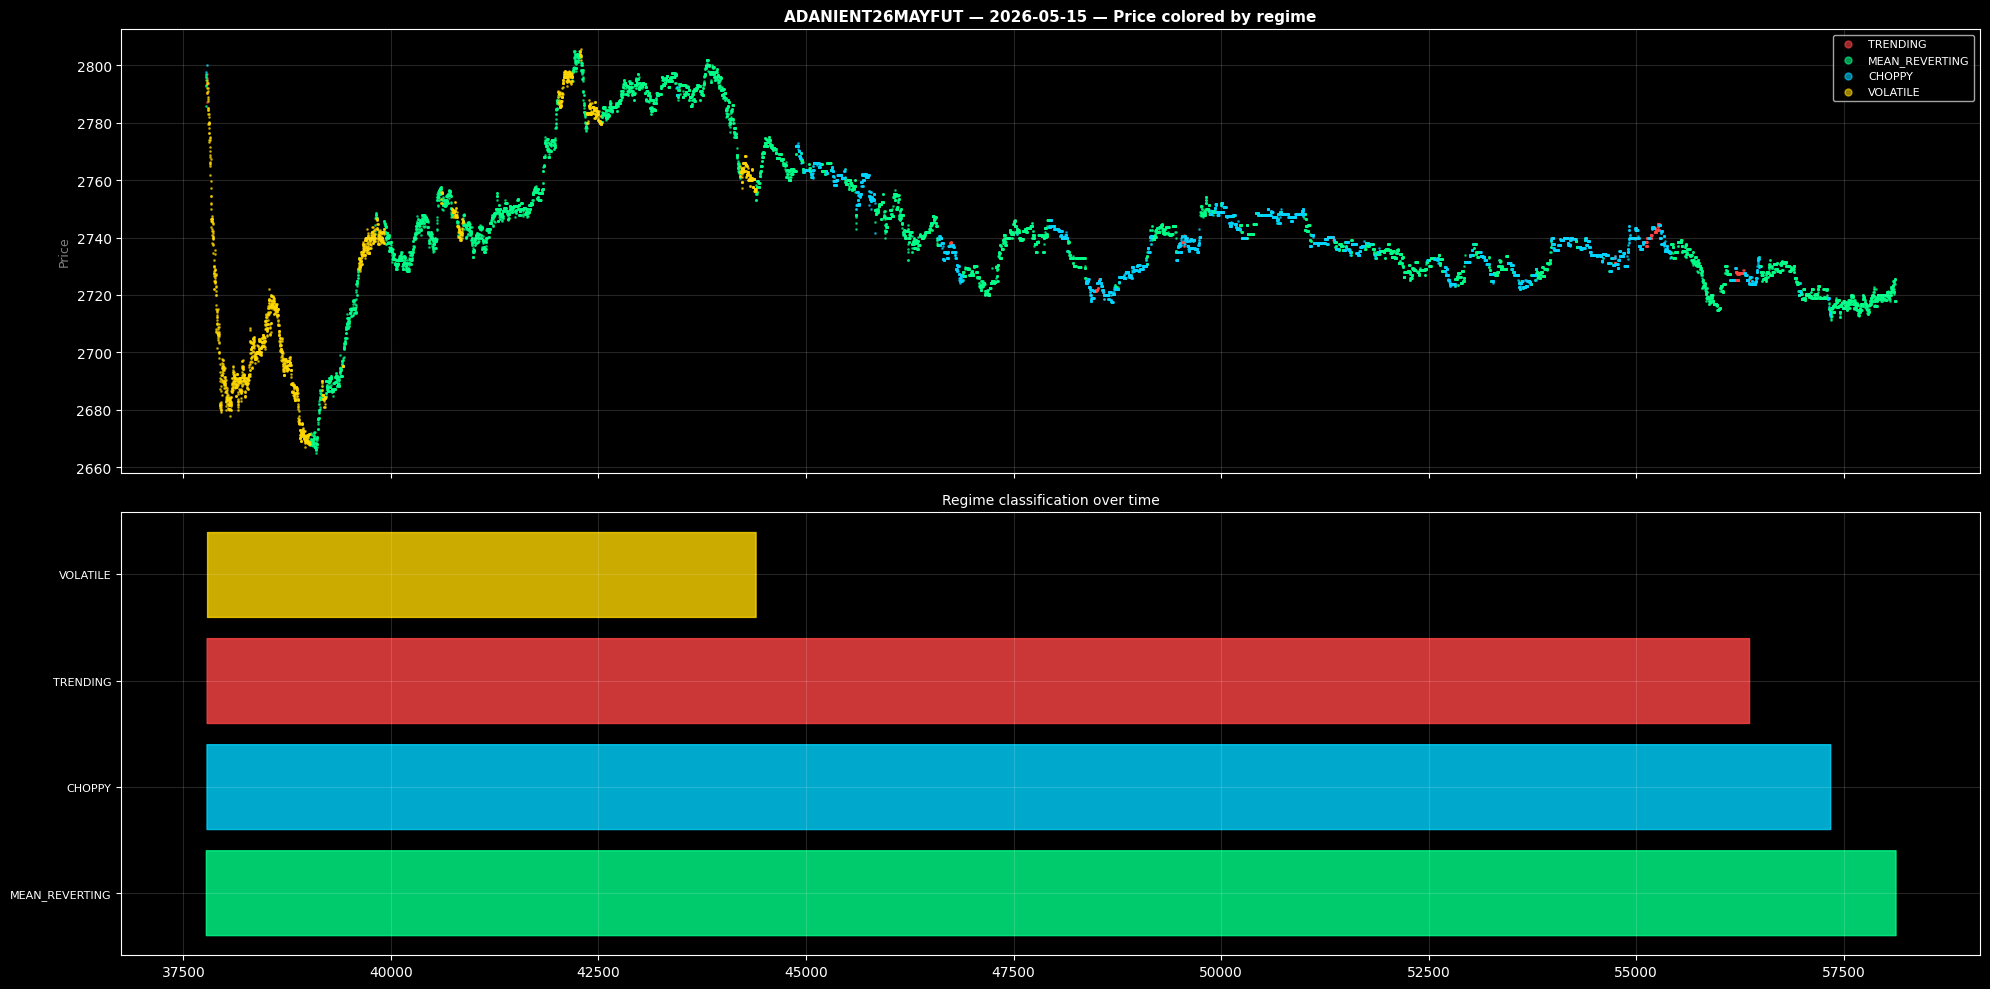

Saved: findings/regime_chart_ADANIENT26MAYFUT_2026-05-15.png


In [9]:
# Pick one symbol and one date for detailed visualization
VIZ_SYM  = 'ADANIENT26MAYFUT'   # most interesting based on prior analysis
VIZ_DATE = '2026-05-15'          # the bad day

df_viz = symbol_data[VIZ_SYM][symbol_data[VIZ_SYM]['date'] == VIZ_DATE].copy()

if not df_viz.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

    # Price chart with regime coloring
    for regime, color in REGIME_COLORS.items():
        mask = df_viz['regime'] == regime
        if mask.any():
            ax1.scatter(df_viz[mask].index, df_viz[mask]['close'],
                        c=color, s=1, alpha=0.6, label=regime)

    ax1.set_title(f'{VIZ_SYM} — {VIZ_DATE} — Price colored by regime',
                  color='white', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Price', color='gray', fontsize=9)
    ax1.legend(fontsize=8, markerscale=5)
    ax1.grid(alpha=0.15)

    # Regime timeline
    regime_num = df_viz['regime'].map({
        MEAN_REVERTING: 0, CHOPPY: 1, TRENDING: 2, VOLATILE: 3
    })
    for regime, color in REGIME_COLORS.items():
        mask = df_viz['regime'] == regime
        ax2.fill_between(df_viz[mask].index,
                         regime_num[mask] - 0.4, regime_num[mask] + 0.4,
                         color=color, alpha=0.8, label=regime)

    ax2.set_yticks([0, 1, 2, 3])
    ax2.set_yticklabels([MEAN_REVERTING, CHOPPY, TRENDING, VOLATILE], fontsize=8)
    ax2.set_title('Regime classification over time', color='white', fontsize=10)
    ax2.grid(alpha=0.15)

    plt.tight_layout()
    plt.savefig(f'../findings/regime_chart_{VIZ_SYM}_{VIZ_DATE}.png',
                dpi=150, bbox_inches='tight', facecolor='black')
    plt.show()
    print(f'Saved: findings/regime_chart_{VIZ_SYM}_{VIZ_DATE}.png')
else:
    print(f'No data for {VIZ_SYM} on {VIZ_DATE}')

## 9. Regime vs PnL Correlation

Does trading during TRENDING regime explain the losses?  
We simulate a simple proxy: count how many bars were in each regime  
on the profitable days (May 13/14) vs bad day (May 15).

In [10]:
# Known PnL results from backtests
KNOWN_PNL = {
    'CHOLAFIN26MAYFUT':   {'2026-05-13': 161107, '2026-05-14':  80000, '2026-05-15': -68342},
    'ADANIPORTS26MAYFUT': {'2026-05-13': 105940, '2026-05-14':  80000, '2026-05-15':  -5308},
    'DRREDDY26MAYFUT':    {'2026-05-13':  62795, '2026-05-14':  50000, '2026-05-15':  23654},
    'ADANIENT26MAYFUT':   {'2026-05-13':  61709, '2026-05-14':  50000, '2026-05-15': -82954},
    'HAVELLS26MAYFUT':    {'2026-05-13':  47164, '2026-05-14':  40000, '2026-05-15':  27693},
    'JSWSTEEL26MAYFUT':   {'2026-05-13':  40215, '2026-05-14':  30000, '2026-05-15':  -8610},
    'RELIANCE26MAYFUT':   {'2026-05-13':  27384, '2026-05-14':  20000, '2026-05-15': -59940},
}

print('Regime % on good vs bad days:')
print()

regime_pnl_data = []
for sym in symbol_data:
    pnl_data = KNOWN_PNL.get(sym, {})
    rbd      = regime_by_day.get(sym, {})

    for date in DATES:
        pnl     = pnl_data.get(date, None)
        r       = rbd.get(date, {})
        if pnl is None or not r:
            continue
        regime_pnl_data.append({
            'symbol':  sym,
            'date':    date,
            'pnl':     pnl,
            'pct_mr':  r.get(MEAN_REVERTING, 0),
            'pct_trending': r.get(TRENDING, 0),
            'pct_choppy':   r.get(CHOPPY, 0),
            'pct_volatile': r.get(VOLATILE, 0),
            'profitable':   pnl > 0,
        })

rp_df = pd.DataFrame(regime_pnl_data)

if not rp_df.empty:
    print('Average regime % by profitable vs losing days:')
    print(rp_df.groupby('profitable')[['pct_mr', 'pct_trending', 'pct_choppy', 'pct_volatile']].mean().round(1))
    print()

    # Correlation between trending% and PnL
    corr_trend = rp_df['pct_trending'].corr(rp_df['pnl'])
    corr_mr    = rp_df['pct_mr'].corr(rp_df['pnl'])
    print(f'Correlation: trending% vs PnL = {corr_trend:.4f}')
    print(f'Correlation: mean-reverting% vs PnL = {corr_mr:.4f}')
    print()
    print('If trending corr is negative and MR corr is positive → regime detection is valid')

Regime % on good vs bad days:

Average regime % by profitable vs losing days:
            pct_mr  pct_trending  pct_choppy  pct_volatile
profitable                                                
False         60.6           4.0        29.5           6.0
True          60.6           6.2        29.3           3.9

Correlation: trending% vs PnL = 0.3084
Correlation: mean-reverting% vs PnL = -0.2212

If trending corr is negative and MR corr is positive → regime detection is valid


## 10. Visualize Regime Distribution by Symbol and Day

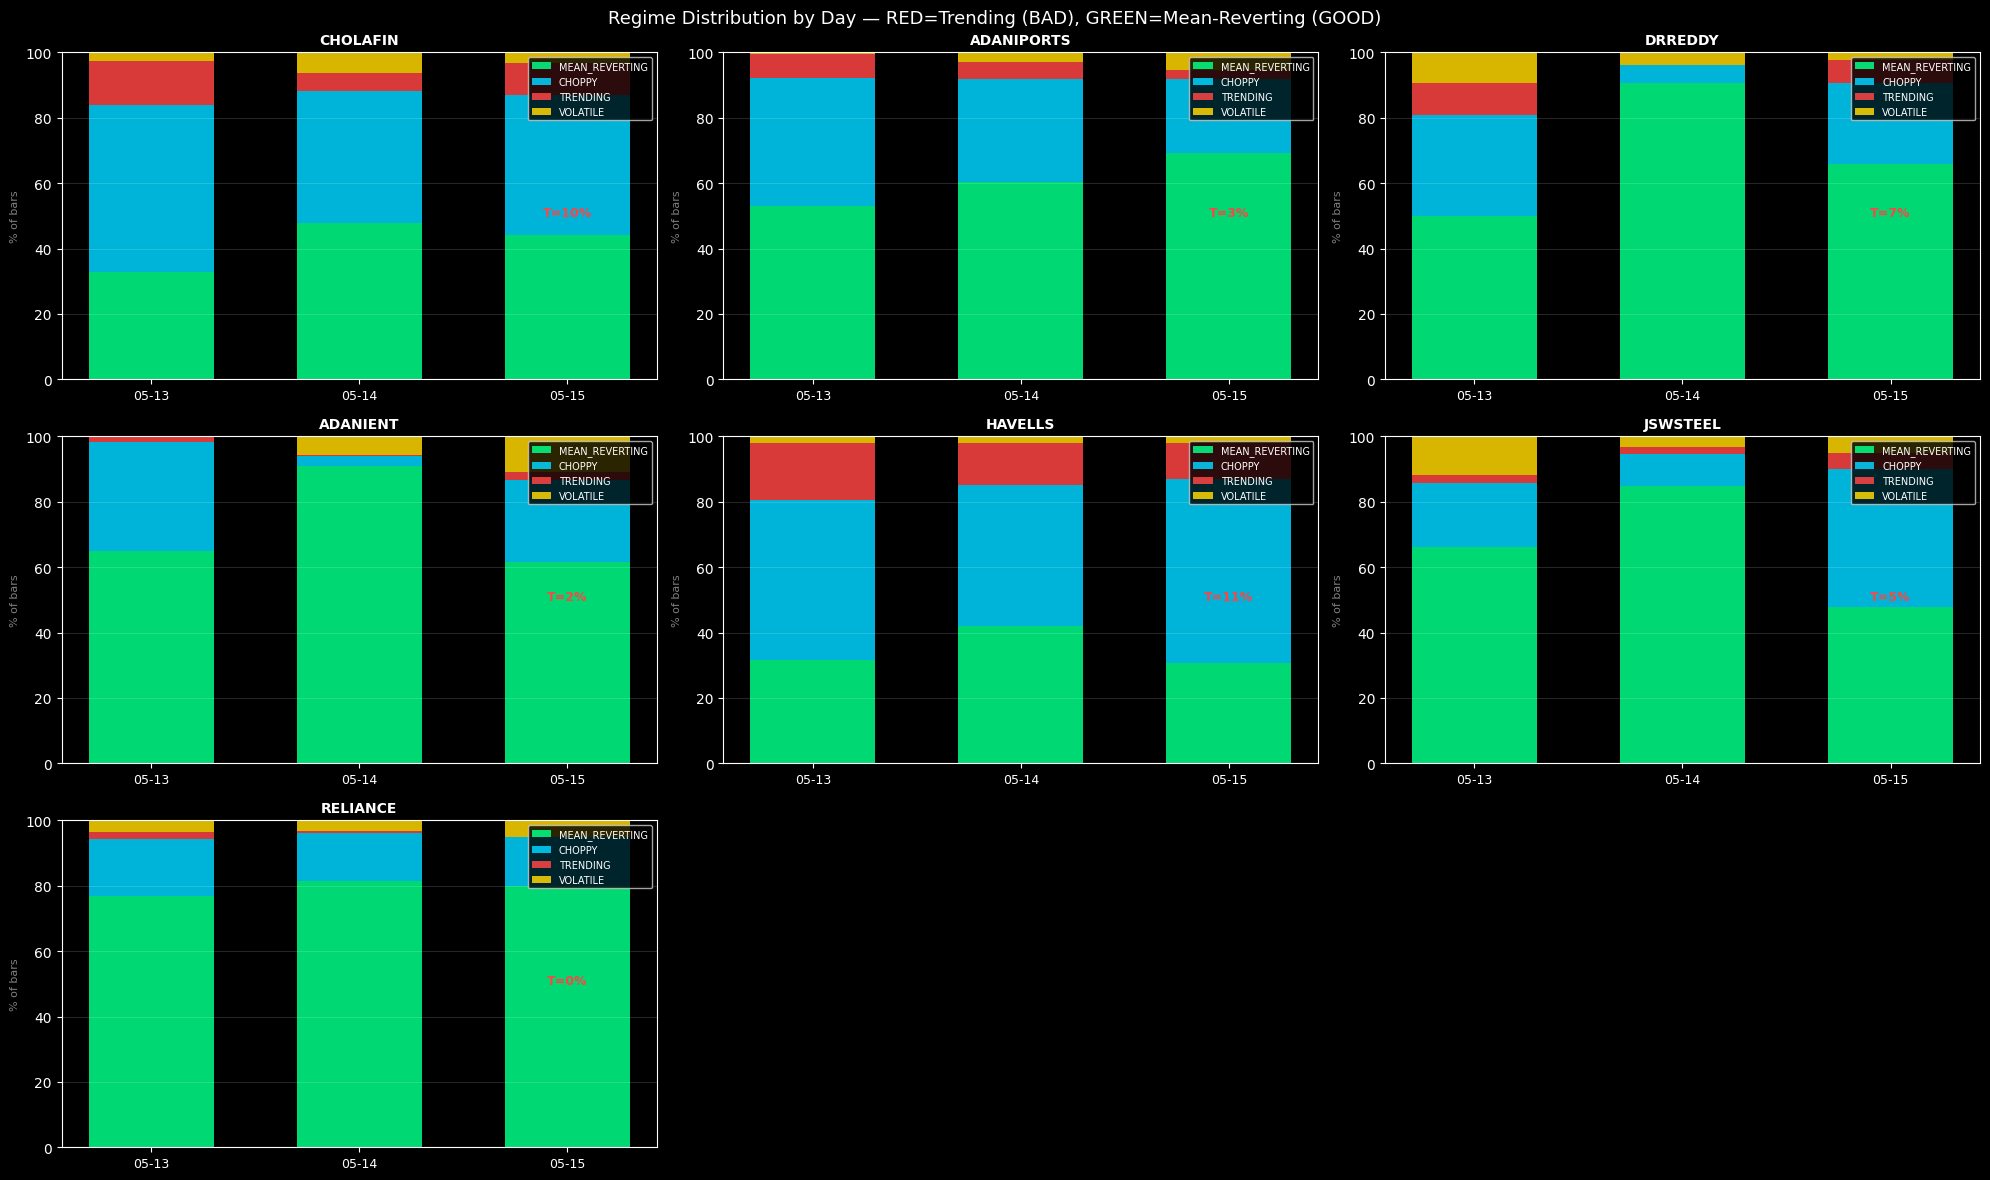

Saved: findings/regime_by_day.png


In [11]:
n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, sym in enumerate(symbol_data):
    ax   = axes[i]
    rbd  = regime_by_day.get(sym, {})
    name = sym.replace('26MAYFUT', '')

    dates_avail = [d for d in DATES if d in rbd]
    if not dates_avail:
        continue

    x      = np.arange(len(dates_avail))
    w      = 0.6
    bottom = np.zeros(len(dates_avail))

    for regime in [MEAN_REVERTING, CHOPPY, TRENDING, VOLATILE]:
        vals = [rbd[d].get(regime, 0) for d in dates_avail]
        ax.bar(x, vals, w, bottom=bottom,
               color=REGIME_COLORS[regime], label=regime, alpha=0.85)
        bottom += np.array(vals)

    ax.set_xticks(x)
    ax.set_xticklabels([d[5:] for d in dates_avail], fontsize=9)
    ax.set_title(name, color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('% of bars', color='gray', fontsize=8)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.15, axis='y')

    # Annotate trending % on May 15
    if '2026-05-15' in rbd:
        t15 = rbd['2026-05-15'].get(TRENDING, 0)
        ax.text(len(dates_avail) - 1, 50, f'T={t15:.0f}%',
                ha='center', color='#ff4444', fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Regime Distribution by Day — RED=Trending (BAD), GREEN=Mean-Reverting (GOOD)',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/regime_by_day.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/regime_by_day.png')

## 11. Momentum Signal Analysis

You have `price_mom_10s`, `price_mom_30s`, `price_mom_60s` pre-computed.  
These are direct trending signals. If |momentum| is high → trending → pause quoting.

In [12]:
mom_analysis = {}

print(f"{'Symbol':30s} {'Mom60s thresh':>14} {'Trend when |m|>thresh':>23} {'Corr mom60→ret':>16}")
print('-' * 88)

for sym, df in symbol_data.items():
    if 'price_mom_60s' not in df.columns:
        print(f'{sym}: price_mom_60s not found')
        continue

    mom = df['price_mom_60s'].dropna()
    mom = mom[mom.abs() < mom.abs().quantile(0.99)]

    # Threshold: P75 of |momentum| = strong momentum signal
    thresh = float(mom.abs().quantile(0.75))

    # When |momentum| > threshold, is regime actually trending?
    df2 = df.copy()
    df2['strong_mom'] = df2['price_mom_60s'].abs() > thresh
    if 'regime' in df2.columns:
        pct_trending_when_strong = float(
            (df2[df2['strong_mom']]['regime'] == TRENDING).mean() * 100
        )
    else:
        pct_trending_when_strong = np.nan

    # Correlation between momentum and forward return
    df2['fwd_ret_60s'] = df2['close'].pct_change(60).shift(-60)
    valid = df2[['price_mom_60s', 'fwd_ret_60s']].dropna()
    corr  = float(valid['price_mom_60s'].corr(valid['fwd_ret_60s']))

    mom_analysis[sym] = {
        'mom60_p75_threshold': round(thresh, 6),
        'pct_trending_when_strong_mom': round(pct_trending_when_strong, 1),
        'mom60_fwd_corr': round(corr, 4),
        'use_as_pause_signal': bool(pct_trending_when_strong > 30 or abs(corr) > 0.05),
    }

    print(f"{sym:30s} {thresh:>14.6f} {pct_trending_when_strong:>22.1f}% {corr:>16.4f}")

print()
print('If pct_trending_when_strong > 30% → use |price_mom_60s| > threshold as pause signal')

Symbol                          Mom60s thresh   Trend when |m|>thresh   Corr mom60→ret
----------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                     0.001082                   11.4%          -0.0511
ADANIPORTS26MAYFUT                   0.001187                    5.9%          -0.0182
DRREDDY26MAYFUT                      0.001437                    8.1%          -0.1494
ADANIENT26MAYFUT                     0.001461                    0.8%          -0.0241
HAVELLS26MAYFUT                      0.000998                   15.5%          -0.1018
JSWSTEEL26MAYFUT                     0.001242                    2.8%          -0.0807
RELIANCE26MAYFUT                     0.000733                    0.6%          -0.0893

If pct_trending_when_strong > 30% → use |price_mom_60s| > threshold as pause signal


## 12. Save Findings

In [13]:
# Load previous findings
vol_path  = os.path.join(FINDINGS_DIR, 'vol_analysis.json')
existing  = json.loads(open(vol_path).read()) if os.path.exists(vol_path) else {}

findings = {}
for sym in symbol_data:
    df = symbol_data[sym]
    r  = df['regime'].value_counts(normalize=True) * 100

    findings[sym] = {
        **{k: v for k, v in existing.get(sym, {}).items()},
        'regime_overall': {
            'pct_mean_reverting': round(float(r.get(MEAN_REVERTING, 0)), 1),
            'pct_choppy':         round(float(r.get(CHOPPY, 0)), 1),
            'pct_trending':       round(float(r.get(TRENDING, 0)), 1),
            'pct_volatile':       round(float(r.get(VOLATILE, 0)), 1),
        },
        'regime_by_day':     regime_by_day.get(sym, {}),
        'return_autocorr':   autocorr_results.get(sym, {}),
        'hurst':             hurst_results.get(sym, {}),
        'variance_ratio':    vr_results.get(sym, {}),
        'momentum_analysis': mom_analysis.get(sym, {}),
        'updated_at':        datetime.now().isoformat(),
    }

output_path = os.path.join(FINDINGS_DIR, 'regime_analysis.json')
with open(output_path, 'w') as f:
    json.dump(findings, f, indent=2, default=str)

print(f'Saved → {output_path}\n')
print(f"{'Symbol':30s} {'H':>6} {'VR(10)':>8} {'MR%':>6} {'Trend%':>8} {'Pause signal?':>15}")
print('-' * 78)
for sym, f_ in findings.items():
    H   = f_.get('hurst', {}).get('H_overall', 'N/A')
    vr  = f_.get('variance_ratio', {}).get('vr10', 'N/A')
    mr  = f_.get('regime_overall', {}).get('pct_mean_reverting', 0)
    tr  = f_.get('regime_overall', {}).get('pct_trending', 0)
    use = f_.get('momentum_analysis', {}).get('use_as_pause_signal', False)
    print(f"{sym:30s} {str(H):>6} {str(vr):>8} {mr:>5.1f}% {tr:>7.1f}% {'YES' if use else 'no':>15}")

Saved → ../findings\regime_analysis.json

Symbol                              H   VR(10)    MR%   Trend%   Pause signal?
------------------------------------------------------------------------------
CHOLAFIN26MAYFUT               0.5379   1.8275  41.5%     9.6%             YES
ADANIPORTS26MAYFUT             0.5231    0.997  60.8%     5.1%              no
DRREDDY26MAYFUT                0.5191   0.7822  65.1%     6.5%             YES
ADANIENT26MAYFUT               0.4932   0.6272  72.9%     1.4%              no
HAVELLS26MAYFUT                0.5305   1.8865  34.7%    13.8%             YES
JSWSTEEL26MAYFUT               0.5099   0.7141  61.4%     3.7%             YES
RELIANCE26MAYFUT               0.4928   0.6463  79.5%     1.0%             YES


## 13. Integration — Regime Filter in mm_strategy.py

In [14]:
print('''
# ── Regime filter in MMStrategy.on_bar() ─────────────────────────────────────

import json
from pathlib import Path
from collections import deque

_REG_PATH  = Path(__file__).parents[2] / 'research' / 'findings' / 'regime_analysis.json'
_REG_DATA  = json.loads(_REG_PATH.read_text()) if _REG_PATH.exists() else {}

# In MMStrategy.__init__:
sym_reg = _REG_DATA.get(symbol, {})
self.mom_thresh = sym_reg.get('momentum_analysis', {}).get('mom60_p75_threshold', 0.001)
self.use_pause  = sym_reg.get('momentum_analysis', {}).get('use_as_pause_signal', False)
self._price_buf = deque(maxlen=300)   # rolling 300s price buffer for VR

# In MMStrategy.on_bar(bar):

# 1. Momentum-based pause (fast, uses pre-computed column)
if self.use_pause:
    mom = abs(bar.get('price_mom_60s', 0))
    if mom > self.mom_thresh:
        return  # strong directional move — stop quoting

# 2. Rolling variance ratio (slower, more robust)
self._price_buf.append(bar['close'])
if len(self._price_buf) >= 60:
    prices = pd.Series(list(self._price_buf))
    rets1  = prices.pct_change().dropna()
    rets10 = prices.pct_change(10).dropna()
    var1   = rets1.var()
    if var1 > 0:
        vr = rets10.var() / (10 * var1)
        if vr > 1.15:  # trending
            return  # pause quoting
''')


# ── Regime filter in MMStrategy.on_bar() ─────────────────────────────────────

import json
from pathlib import Path
from collections import deque

_REG_PATH  = Path(__file__).parents[2] / 'research' / 'findings' / 'regime_analysis.json'
_REG_DATA  = json.loads(_REG_PATH.read_text()) if _REG_PATH.exists() else {}

# In MMStrategy.__init__:
sym_reg = _REG_DATA.get(symbol, {})
self.mom_thresh = sym_reg.get('momentum_analysis', {}).get('mom60_p75_threshold', 0.001)
self.use_pause  = sym_reg.get('momentum_analysis', {}).get('use_as_pause_signal', False)
self._price_buf = deque(maxlen=300)   # rolling 300s price buffer for VR

# In MMStrategy.on_bar(bar):

# 1. Momentum-based pause (fast, uses pre-computed column)
if self.use_pause:
    mom = abs(bar.get('price_mom_60s', 0))
    if mom > self.mom_thresh:
        return  # strong directional move — stop quoting

# 2. Rolling variance ratio (slower, more robust)
self._price_buf.append(bar['close'])
if len(self._price_buf) >= 60:
    prices 

## 14. Conclusions

*(Fill in after running)*

### Key Questions to Answer
1. What is the Hurst exponent for each symbol? (overall mean-reverting or trending?)
2. Was May 15 more trending than May 13/14? (explains the bad backtest)
3. Is the correlation between trending% and PnL negative? (validates the approach)
4. Does |price_mom_60s| > threshold reliably predict trending regime?
5. What % of trading time is in trending regime? (how often would we pause?)

### Action Items
- [ ] Add momentum-based pause to `mm_strategy.py` (integration code above)
- [ ] Re-run May 15 backtest with regime filter — expect significant improvement
- [ ] Add rolling VR calculation for real-time regime detection
- [ ] Next: Combine dynamic σ (notebook 03) + regime filter → full implementation in `mm_strategy.py`

### Expected Impact
If trending regime = 20-30% of trading time and we pause during those periods:
- Lose ~20-30% of fill opportunities
- But avoid the losses that come from trending adverse selection
- Net PnL should improve significantly on bad days like May 15
- Good days (May 13/14) should be largely unaffected